# how many in each directory

In [28]:
import os
import json
count = 0
for f in os.listdir("/Users/ayu/PDF_benchmarking/getJSON/outJSON/OllamaOut"):
    if f.endswith(".json"):
        file_path = os.path.join("/Users/ayu/PDF_benchmarking/getJSON/outJSON/OllamaOut", f)
        try:
            with open(file_path, 'r') as file:
                data = json.load(file)
                if data.get("error") == "Model returned None response":
                    count += 1
                    os.remove(file_path)
        except json.JSONDecodeError:
            print(f"Invalid JSON file removed: {f}")
            os.remove(file_path)
            count += 1
        except Exception as e:
            print(f"Error processing file {f}: {e}")
print(f"Removed {count} files with 'Model returned None response' error or invalid JSON.")


Invalid JSON file removed: 25ee52d7-5727-4594-a2ef-fb5adefa62a0_llama3.1_70b__distressed__response.json
Removed 149 files with 'Model returned None response' error or invalid JSON.


In [3]:
import os
import pprint
ollama = {'OllamaOut': 0, 'OllamaOutNP': 0, 'OllamaVisionOut': 0, 'OllamaVisionOutNP': 0}
openai = {'OpenAIOut': 0, 'OpenAIOutNP': 0, 'OpenAIVisionOut':0, 'OpenAIVisionOutNP': 0}
for d in os.listdir("/Users/ayu/PDF_benchmarking/getJSON/outJSON"):
    if d.startswith("OllamaOut") or d.startswith("OllamaOutNP") or d.startswith("OllamaVisionOut") or d.startswith("OllamaVisionOutNP"):
        fac = 3
        if d.startswith("OllamaVisionOut") or d.startswith("OllamaVisionOutNP"):
            fac = 2
        ollama[d] += len(os.listdir(f"/Users/ayu/PDF_benchmarking/getJSON/outJSON/{d}")) / fac # type: ignore
    elif "openai" in d.lower():
        fac = 1
        openai[d] += len(os.listdir(f"/Users/ayu/PDF_benchmarking/getJSON/outJSON/{d}")) / fac # type: ignore
    elif "out" in d.lower():
        print(len(os.listdir(f"/Users/ayu/PDF_benchmarking/getJSON/outJSON/{d}")), d)

print ("Ollama JSONs:")
pprint.pprint(ollama)
print ("OpenAI JSONs:")
pprint.pprint(openai)


723 localout
4000 glinerOut
Ollama JSONs:
{'OllamaOut': 854.6666666666666,
 'OllamaOutNP': 904.0,
 'OllamaVisionOut': 912.0,
 'OllamaVisionOutNP': 930.0}
OpenAI JSONs:
{'OpenAIOut': 2000.0,
 'OpenAIOutNP': 941.0,
 'OpenAIVisionOut': 1798.0,
 'OpenAIVisionOutNP': 1888.0}


In [20]:
import pandas as pd
df = pd.read_csv("Hospital3.csv")
df_grouped = df.groupby(["LLM", "Prompt"]).LLM.value_counts()
df_grouped

LLM                       Prompt       
gemma327b                 LTNER/GPT-NER    1222
                          Normal            432
gemma327b*ImageInput*     LTNER/GPT-NER    1642
                          Normal           1310
gpt-4.1-mini              LTNER/GPT-NER     941
                          Normal            850
gpt-4.1-mini*ImageInput*  LTNER/GPT-NER    1888
                          Normal           1798
llama3.170b               LTNER/GPT-NER    1460
                          Normal            584
mistral(24b)              LTNER/GPT-NER    1462
                          Normal            587
mistral(24b)*ImageInput*  LTNER/GPT-NER    1642
                          Normal           1392
Name: count, dtype: int64

In [8]:
import json
for d in os.listdir("/Users/ayu/PDF_benchmarking/getJSON/outJSON"):
    if d.startswith("OllamaOut") or d.startswith("OllamaOutNP") or d.startswith("OllamaVisionOut") or d.startswith("OllamaVisionOutNP"):
        for f in  os.listdir(f"/Users/ayu/PDF_benchmarking/getJSON/outJSON/{d}/"):
            with open(f"/Users/ayu/PDF_benchmarking/getJSON/outJSON/{d}/{f}", "r") as file:
                try: 
                    data = json.load(file)
                    if "failed" == data.get("status", ""):
                        print(f"Failed JSON in {d}: {f}")
                        os.remove(f"/Users/ayu/PDF_benchmarking/getJSON/outJSON/{d}/{f}")
                except json.JSONDecodeError:
                    os.remove(f"/Users/ayu/PDF_benchmarking/getJSON/outJSON/{d}/{f}")
                    print(f"JSON decode error in {d}: {f}")
                    continue
                


In [23]:
import pandas as pd
df = pd.read_csv("Hospital3.csv")
df.drop(columns=[col for col in df.columns if col.startswith("Unnamed:")], inplace=True)
df.LLM.value_counts()

LLM
gpt-4.1-mini*ImageInput*        3686
mistral(24b)*ImageInput*        3034
gemma327b*ImageInput*           2952
mistral(24b)                    2049
llama3.170b                     2044
GLiNER                          2000
Ihor/gliner-biomed-base-v1.0    2000
gpt-4.1-mini                    1791
gemma327b                       1654
NuExtract:4B                     723
Name: count, dtype: int64

In [24]:
df.groupby(["LLM"]).Prompt.value_counts()

LLM                       Prompt       
gemma327b                 LTNER/GPT-NER    1222
                          Normal            432
gemma327b*ImageInput*     LTNER/GPT-NER    1642
                          Normal           1310
gpt-4.1-mini              LTNER/GPT-NER     941
                          Normal            850
gpt-4.1-mini*ImageInput*  LTNER/GPT-NER    1888
                          Normal           1798
llama3.170b               LTNER/GPT-NER    1460
                          Normal            584
mistral(24b)              LTNER/GPT-NER    1462
                          Normal            587
mistral(24b)*ImageInput*  LTNER/GPT-NER    1642
                          Normal           1392
Name: count, dtype: int64

# Model Performance by Hospital Template

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Configure matplotlib for publication quality
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']
rcParams['font.size'] = 10
rcParams['axes.labelsize'] = 12
rcParams['axes.titlesize'] = 14
rcParams['xtick.labelsize'] = 10
rcParams['ytick.labelsize'] = 10
rcParams['legend.fontsize'] = 10
rcParams['figure.titlesize'] = 16

# Load and preprocess data
df = pd.read_csv('Hospital2.csv')
df.drop(columns=[col for col in df.columns if 'unnamed' in col.lower()], inplace=True)  
df["Image"] = df["LLM"].str.contains("ImageInput")
df["LLM"] = df["LLM"].str.replace("Ihor/gliner-biomed-base-v1.0", "BioGliNER", regex=False)

Text-based models - Mean F1: 17.632 ± 18.221
Vision-based models - Mean F1: 28.765 ± 12.649


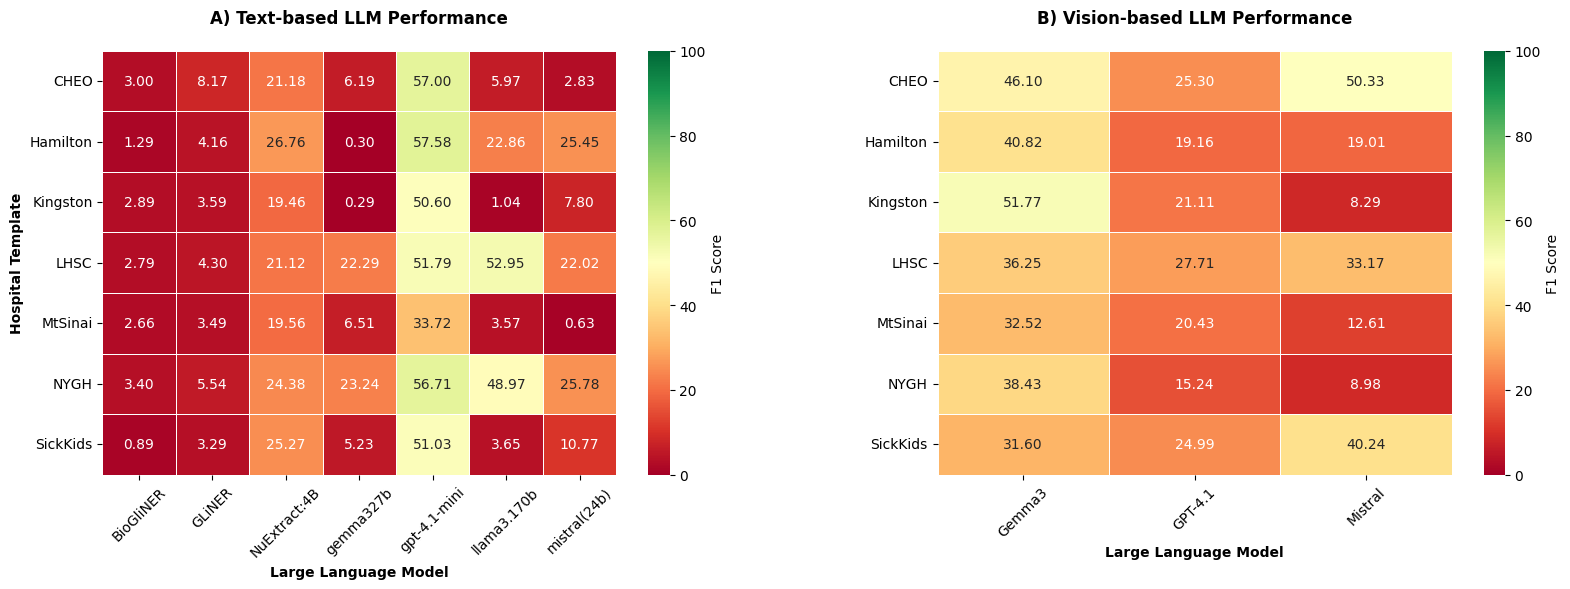

In [12]:
# Prepare data for both heatmaps
text_models = df[df["Image"] == False].groupby(["Hospital", "LLM"]).F1score.mean().unstack()
vision_models = df[df["Image"] == True].groupby(["Hospital", "LLM"]).F1score.mean().unstack()

# Set up the figure with publication-quality styling
plt.style.use('default')  # Reset to default style
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Define consistent color scheme
cmap = 'RdYlGn'  # Red-Yellow-Green colormap for better accessibility
vmin, vmax = 0, 100  # Set consistent scale for both plots

# Plot A: Text-based models
im1 = sns.heatmap(text_models, 
                  annot=True, 
                  fmt='.2f', 
                  cmap=cmap,
                  vmin=vmin,
                  vmax=vmax,
                  cbar_kws={'label': 'F1 Score'},
                  ax=ax1,
                  linewidths=0.5,
                  linecolor='white')

ax1.set_title('A) Text-based LLM Performance', fontweight='bold', pad=20)
ax1.set_xlabel('Large Language Model', fontweight='bold')
ax1.set_ylabel('Hospital Template', fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.tick_params(axis='y', rotation=0)

# Plot B: Vision-based models
im2 = sns.heatmap(vision_models, 
                  annot=True, 
                  fmt='.2f', 
                  cmap=cmap,
                  vmin=vmin,
                  vmax=vmax,
                  cbar_kws={'label': 'F1 Score'},
                  ax=ax2,
                  linewidths=0.5,
                  linecolor='white')

ax2.set_title('B) Vision-based LLM Performance', fontweight='bold', pad=20)
ax2.set_xlabel('Large Language Model', fontweight='bold')
ax2.set_ylabel('Hospital Template', fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.tick_params(axis='y', rotation=0)
ax2.set_xticklabels(["Gemma3", "GPT-4.1", "Mistral"])
# Remove y-axis labels from second plot to avoid redundancy
ax2.set_ylabel('')

# Adjust layout for publication
plt.tight_layout()
plt.subplots_adjust(wspace=0.3)  # Add space between subplots

# Display summary statistics
print(f"Text-based models - Mean F1: {text_models.values.flatten().mean():.3f} ± {text_models.values.flatten().std():.3f}")
print(f"Vision-based models - Mean F1: {vision_models.values.flatten().mean():.3f} ± {vision_models.values.flatten().std():.3f}")

plt.show()

# Save high-quality figure for publication
fig.savefig('figure_llm_performance_comparison.pdf', 
            dpi=300, 
            bbox_inches='tight',
            facecolor='white',
            edgecolor='none')
fig.savefig('figure_llm_performance_comparison.png', 
            dpi=300, 
            bbox_inches='tight',
            facecolor='white',
            edgecolor='none')

In [9]:

# Chi-square test for Hospital Template vs F1 Score Performance Categories
from scipy.stats import chi2_contingency
import pandas as pd

# Create performance categories for F1 scores
def categorize_f1_score(score):
    if pd.isna(score):
        return 'Missing'
    elif score >= 80:
        return 'High (≥80)'
    elif score >= 60:
        return 'Medium (60-79)'
    elif score >= 40:
        return 'Low (40-59)'
    else:
        return 'Very Low (<40)'

# Add performance category column
df['F1_Category'] = df['F1score'].apply(categorize_f1_score)

# Create contingency table
contingency_table = pd.crosstab(df['Hospital'], df['F1_Category'])
print("Contingency Table: Hospital Template vs F1 Score Categories")
print(contingency_table)
print("\n")

# Perform chi-square test
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Test Results:")
print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"Significant association: {'Yes' if p_value < 0.05 else 'No'} (α = 0.05)")

# Calculate Cramér's V (effect size)
n = contingency_table.sum().sum()
cramers_v = np.sqrt(chi2_stat / (n * (min(contingency_table.shape) - 1)))
print(f"Cramér's V (effect size): {cramers_v:.4f}")

# Interpretation of effect size
if cramers_v < 0.1:
    effect_size = "negligible"
elif cramers_v < 0.3:
    effect_size = "small"
elif cramers_v < 0.5:
    effect_size = "medium"
else:
    effect_size = "large"
print(f"Effect size interpretation: {effect_size}")

# Show expected frequencies
print("\nExpected Frequencies:")
expected_df = pd.DataFrame(expected, 
                          index=contingency_table.index, 
                          columns=contingency_table.columns)
print(expected_df.round(2))

Contingency Table: Hospital Template vs F1 Score Categories
F1_Category  High (≥80)  Low (40-59)  Medium (60-79)  Missing  Very Low (<40)
Hospital                                                                     
CHEO                 11          740             433      520            2689
Hamilton            153          630             170      832            3562
Kingston              1          666             269      622            3615
LHSC                 23          604             499      264            2911
MtSinai               0          346              12      551            4228
NYGH                 88          393             489      254            3592
SickKids             31          418             286      943            2931


Chi-Square Test Results:
Chi-square statistic: 2351.7095
p-value: 0.0000
Degrees of freedom: 24
Significant association: Yes (α = 0.05)
Cramér's V (effect size): 0.1319
Effect size interpretation: small

Expected Frequencies:
F1_Categor

# Statistical Analysis

In [7]:
from scipy import stats

# Perform statistical comparison between text and vision models
text_scores = df[df["Image"] == False]['F1score'].dropna()
vision_scores = df[df["Image"] == True]['F1score'].dropna()

# Welch's t-test (unequal variances)
t_stat, p_value = stats.ttest_ind(text_scores, vision_scores, equal_var=False)

print("Statistical Comparison of Text vs Vision Models:")
print(f"Text models: n={len(text_scores)}, Mean={text_scores.mean():.3f}, SD={text_scores.std():.3f}")
print(f"Vision models: n={len(vision_scores)}, Mean={vision_scores.mean():.3f}, SD={vision_scores.std():.3f}")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.3f}")
print(f"Significant difference: {'Yes' if p_value < 0.05 else 'No'} (α = 0.05)")

Statistical Comparison of Text vs Vision Models:
Text models: n=5786, Mean=11.382, SD=21.178
Vision models: n=607, Mean=28.581, SD=19.816
t-statistic: -20.207
p-value: 0.000
Significant difference: Yes (α = 0.05)


In [8]:
df["Prompt"].fillna("No Prompt", inplace=True)
df.groupby(["Prompt"]).LLM.value_counts().head(20)

/var/folders/2r/vpjdzw2s7jl5204hqh_k3c9h0000gp/T/ipykernel_65736/762143792.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Prompt"].fillna("No Prompt", inplace=True)


Prompt         LLM                     
LTNER/GPT-NER  gemma327b                    154
               gpt-4.1-mini                 154
               llama3.170b                  154
               mistral(24b)                 154
               gemma327b*ImageInput*         77
               gpt-4.1-mini*ImageInput*      77
               mistral(24b)*ImageInput*      77
No Prompt      GLiNER                      4154
               NuExtract:4B                 128
Normal         mistral(24b)                 481
               gemma327b                    480
               llama3.170b                  480
               gemma327b*ImageInput*        170
               mistral(24b)*ImageInput*     170
               gpt-4.1-mini                 154
               gpt-4.1-mini*ImageInput*      77
Name: count, dtype: int64